<a href="https://www.kaggle.com/code/sonawanelalitsunil/tweet-sentiment-classifier-ml-100?scriptVersionId=235780671" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tweet-sentiment-classification-dataset/tweet_sentiment.csv


## Title: Tweet Sentiment Classifier Dataset

#### Description: A labeled dataset of tweets categorized by sentiment (positive, negative, neutral), useful for training and evaluating sentiment analysis models.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/tweet-sentiment-classification-dataset/tweet_sentiment.csv')

In [3]:
df.head()

,tweet,sentiment
0,The event starts at 5 PM.,neutral
1,I hate how this turned out.,negative
2,Fantastic experience!,positive
3,Fantastic experience!,positive
4,This is the worst thing ever!,negative


In [4]:
df.tail()

,tweet,sentiment
995,It’s cloudy outside.,neutral
996,Great job by the team!,positive
997,I'm so happy about the news!,positive
998,It ruined my whole day.,negative
999,I'm sick of this happening.,negative


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet      1000 non-null   object
 1   sentiment  1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [6]:
df.describe()

,tweet,sentiment
count,1000,1000
unique,17,3
top,Fantastic experience!,positive
freq,71,396


In [7]:
df.isnull().sum()

tweet        0
sentiment    0
dtype: int64

In [8]:
df.duplicated().sum()

983

In [9]:
df.dtypes

tweet        object
sentiment    object
dtype: object

In [10]:
df.shape

(1000, 2)

In [11]:
df.columns

Index(['tweet', 'sentiment'], dtype='object')

## Data visualizations

In [12]:
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

In [13]:
# Download stopwords if not already
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

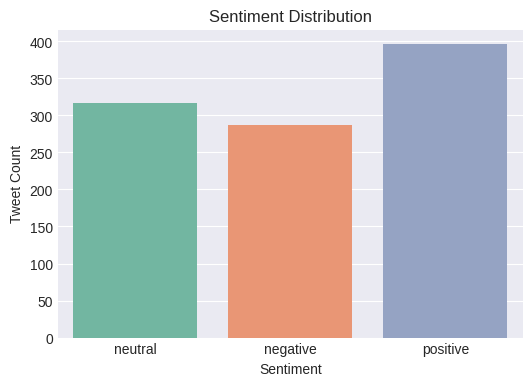

In [14]:
# Basic setup
plt.style.use('seaborn-darkgrid')
stop_words = set(stopwords.words('english'))

# 1. Sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Tweet Count')
plt.show()


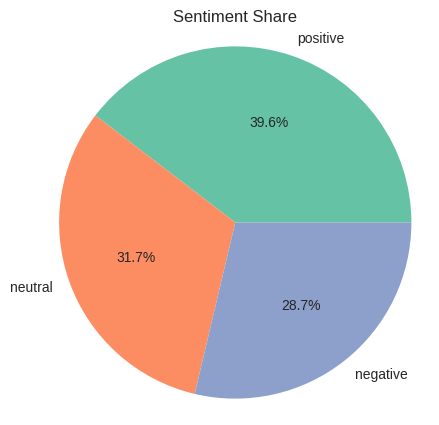

In [15]:
# 2. Pie chart of sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Sentiment Share')
plt.axis('equal')
plt.show()


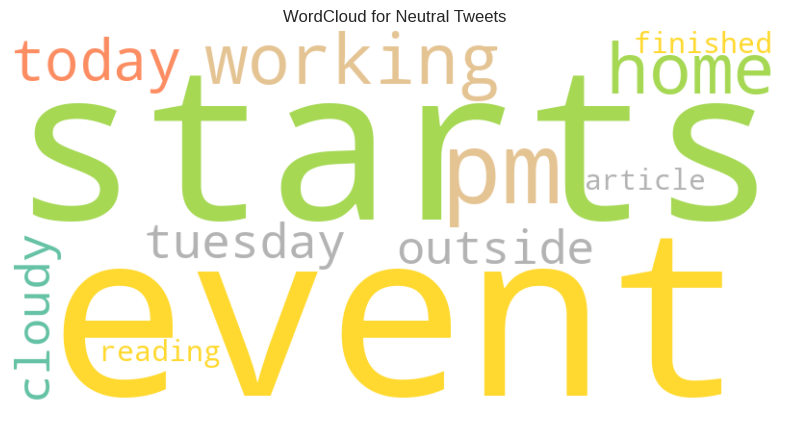

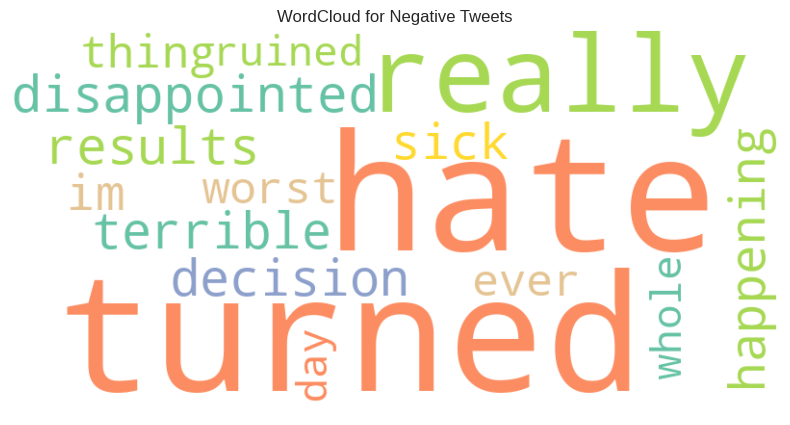

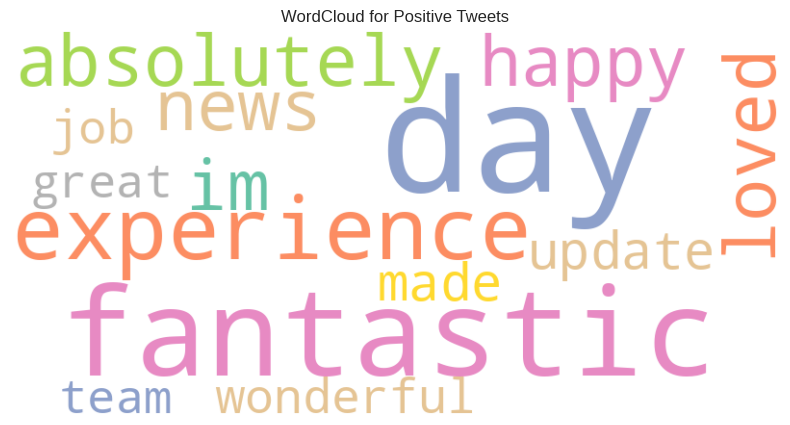

In [16]:
# 3. WordClouds for each sentiment
def clean_text(text):
    words = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    return [word for word in words if word not in stop_words and word.isalpha()]

for sentiment in df['sentiment'].unique():
    all_words = df[df['sentiment'] == sentiment]['tweet'].dropna().apply(clean_text).sum()
    word_freq = Counter(all_words)
    wc = WordCloud(width=800, height=400, background_color='white', colormap='Set2').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud for {sentiment.capitalize()} Tweets')
    plt.show()


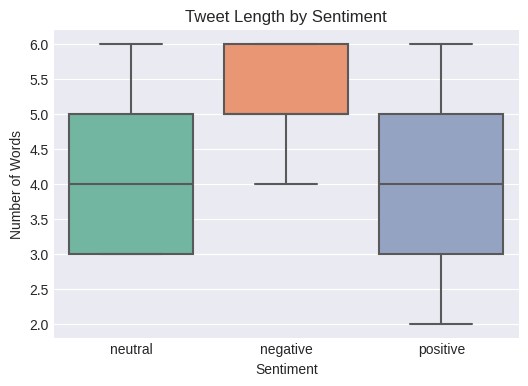

In [17]:
# 4. Average tweet length per sentiment
df['tweet_length'] = df['tweet'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='sentiment', y='tweet_length', palette='Set2')
plt.title('Tweet Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [19]:
# Drop NaNs if any
df.dropna(subset=['tweet', 'sentiment'], inplace=True)

# Encode target labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

# TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['tweet'])
y = df['label']

In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
# Models to compare
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM (Linear)': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

Naive Bayes Accuracy: 100.00%


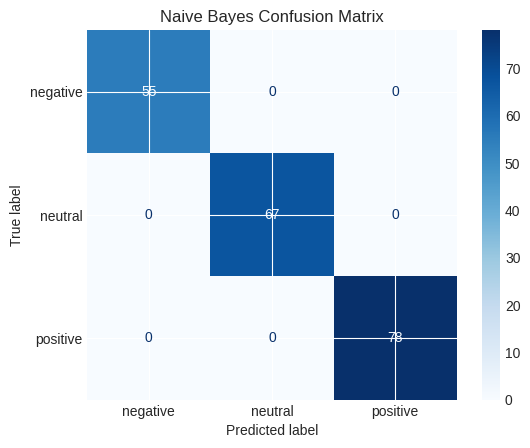

Logistic Regression Accuracy: 100.00%


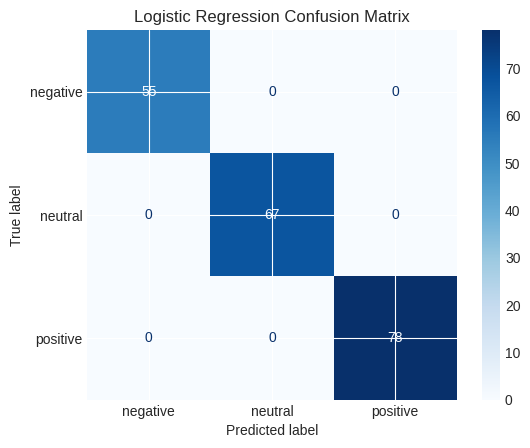

SVM (Linear) Accuracy: 100.00%


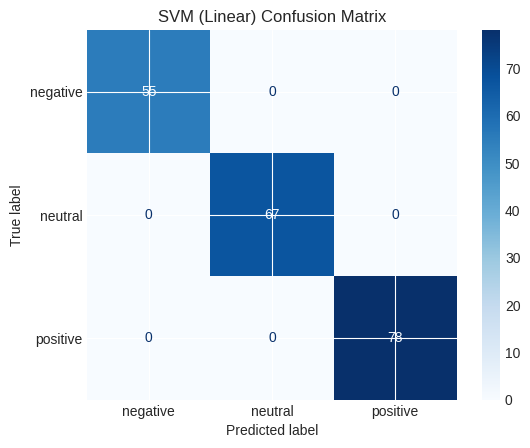

Random Forest Accuracy: 100.00%


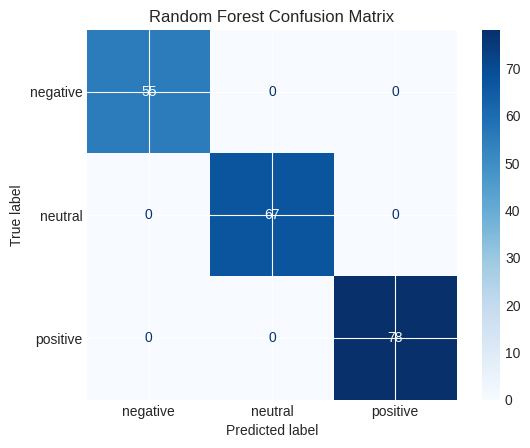

K-Nearest Neighbors Accuracy: 100.00%


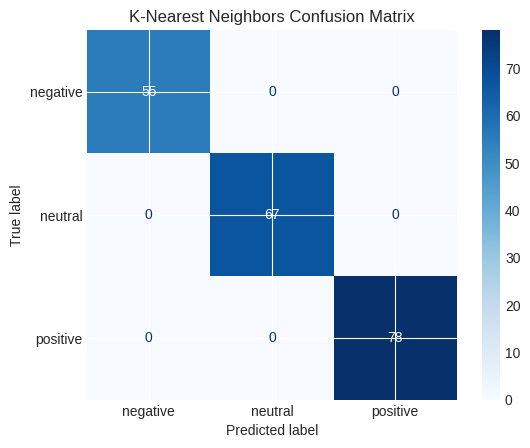

In [22]:
# Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    print(f'{name} Accuracy: {acc:.2f}%')
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()


## Thank you..pls upvote!!